In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import os
import re 
import sys
import datetime
import random
from pathlib import Path
import warnings
import cartopy.feature as cfeature
import cartopy.crs as ccrs

In [4]:
narclim_path = '/g/data/zz63/NARCliM2-0-derived/output-CMIP6/bias-adjusted-output/NARCliM2-0-SEAus-04/NSW-Government/ACCESS-ESM1-5/historical/r6i1p1f1/NARCliM2-0-WRF412R3/v1-r1-NSWGovernment-CDF-AGCDv1-1990-2009/day/prAdjust/v20241122/'
narclim_file = 'prAdjust_NARCliM2-0-SEAus-04_ACCESS-ESM1-5_historical_r6i1p1f1_NSW-Government_NARCliM2-0-WRF412R3_v1-r1-NSWGovernment-CDF-AGCDv1-1990-2009_day_20140101-20141231.nc'

narclim_ds = xr.open_dataset(narclim_path + narclim_file, engine='h5netcdf')

In [9]:
rlon_correction_file = '/g/data/zz63/NARCliM2-0/rlon-correction-NARCliM2-0-SEAus-04.txt'
rlon_corrected = open(rlon_correction_file).read().splitlines()

rotated_pole = ccrs.RotatedPole(pole_longitude=141.38,   # West longitude
                                pole_latitude=60.31)     # North latitude

In [10]:
narclim_ds['rlon'] = rlon_corrected

In [12]:
def convert_precip_kg_m2_s_to_mm_day(precip_kg_m2_s):
    # Convert kg/m²/s to mm/day
    precip_mm_day = precip_kg_m2_s * 86400  # 1 day = 86400 seconds
    return precip_mm_day

narclim_precip = convert_precip_kg_m2_s_to_mm_day(narclim_ds['prAdjust'])

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


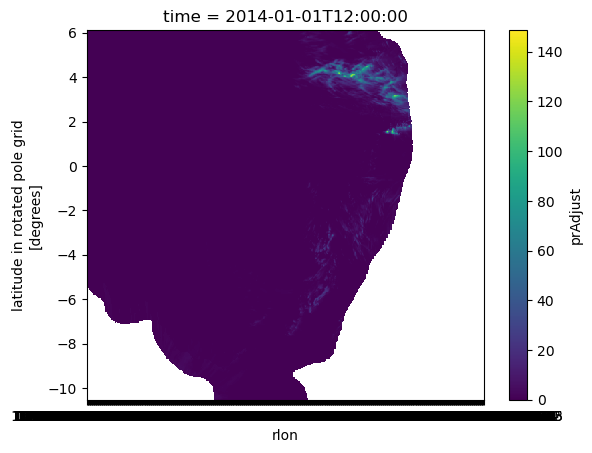

In [15]:
narclim_precip.isel(time=0).plot()

In [6]:
def open_and_prepare_variable(data_root, var_name,start_time=None,end_time=None):
    """
    Open and prepare the dataset of a variable.
    """
    def _preprocess(ds): 
        ds = ds[(list(ds.keys()))[0]]
        return ds
    
    latest_data_root = Path(os.path.join(data_root, var_name, "latest"))
    file_paths = [fp for fp in (latest_data_root.glob("*.nc")) if re.search(var_name,fp.name)]
    file_paths.sort()
    dataset = xr.open_mfdataset(file_paths, parallel=True, preprocess=_preprocess, engine="h5netcdf", join='outer', chunks={"time":-1})    
    os.chdir("/g/data/zz63/NARCliM2-0/")
    a = (open('rlon-correction-NARCliM2-0-SEAus-04.txt'))
    #a = (open('rlon-correction-AUS-18.txt'))
    b = a.read().splitlines()
    dataset['rlon'] = b
    if start_time is None:
        start_time = np.ravel(dataset.time[0].dt.strftime("%Y-%m-%d"))[0]
    if end_time is None:
        end_time = np.ravel(dataset.time[-1].dt.strftime("%Y-%m-%d"))[0]
    dataset = dataset.sel(time=slice(start_time,end_time))
    return dataset

In [7]:
narclim_ds = open_and_prepare_variable(narclim_path, 'prAdjust',start_time='2013-01-01',end_time='2014-30-12')

OSError: no files to open

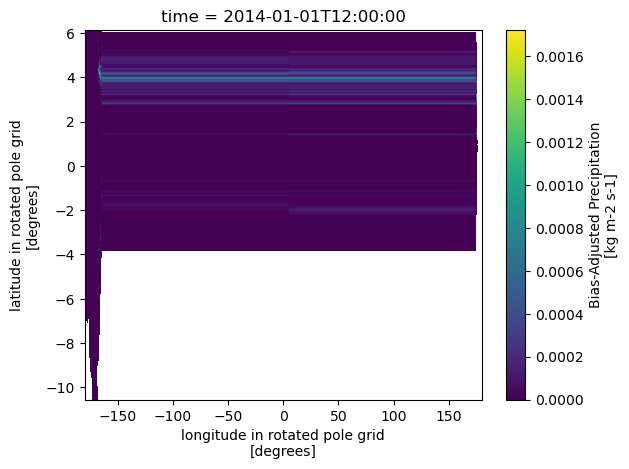

In [ ]:
narclim_ds.isel(time=0).prAdjust.plot()